In [1]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import RandomForestClassifier
from treeinterpreter import treeinterpreter as ti
import matplotlib.pyplot as plt
import seaborn as sns
import protpy as protpy
from Bio import SeqIO
import pandas as pd
import numpy as np
from Bio.Align import substitution_matrices
S=substitution_matrices.load("PAM30")

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import  LeaveOneGroupOut
from sklearn.metrics import confusion_matrix
from sklearn.metrics import fbeta_score, make_scorer
import sklearn
from sklearn import metrics
from scipy.stats import pearsonr, spearmanr

def pearson(y_true, y_pred):
    r_val, p_val = pearsonr(x=y_true, y=y_pred)
    return r_val


regress_scoring = {
    'pearsonr': make_scorer(pearson)
}


In [2]:
X_train = []
Y_train = []
strat = []
#"H5N1","H9N2"
for cnt,u in enumerate(["H1N1","H3N2","H5N1","H9N2"]):
    
    dat = pd.read_csv("HI_assay/curate_02/"+u+"_antigenicData", header=None,sep="\t")
    seq_ =  SeqIO.to_dict(SeqIO.parse("HI_assay/curate_02/"+u+"_AA.fa", "fasta"))
    struct_pos = pd.read_csv("HI_assay/curate_02/band/epitopeByDist2top_"+u[:2], header=None)

    for i in range(dat.shape[0]):
        s1 = dat.iloc[i,0]
        s2 = dat.iloc[i,1]
        score_train = dat.iloc[i,2]

        s1_seq = str(seq_[s1].seq)
        s2_seq = str(seq_[s2].seq)

        #get score
        score_ = {}
        for j in range(len(s1_seq)):

            pos_1 = s1_seq[j]
            pos_2 = s2_seq[j]

            if pos_1 == "-" or pos_2 == "-":
                pass
            else:
                score_[j] = S[pos_1,pos_2]

        #get band
        score_band = []
        for k in range(10):
            ban=struct_pos.iloc[k,:]
            index_ = ban.tolist()[0].split('\t')[1:]
            QC_index = [int(z)-1 for z in index_]

            sum_in = []
            for ss in QC_index:
                try:
                    sum_in.append(score_[ss])
                except:
                    pass

            sb = np.mean(sum_in)
            score_band.append(sb)
        X_train.append(score_band)
        Y_train.append(score_train)
        strat.append(cnt)

In [3]:
#4. Model develop

In [4]:
from sklearn.model_selection import KFold
kf = KFold(n_splits=5)
logo = LeaveOneGroupOut()
X_train_array = np.array(X_train)
Y_train_array = np.array(Y_train)
group = np.array(strat)    

In [22]:
perf = []
from sklearn import linear_model
from sklearn.svm import LinearSVR


#for i, (train_index, test_index) in enumerate(logo.split(X_train_array,Y_train_array,group)):
for i, (train_index, test_index) in enumerate(kf.split(X_train_array)):
    
    param_grid = {'max_depth': [32],
                  'min_samples_split':[5],
                  'min_samples_leaf':[5],
                  'max_samples':[0.9],
                  'ccp_alpha': [0.9],
                  'n_estimators':[8]}
    
    

    param_grid = {'C': [1,5,10],
                  'tol': [0.1,0.2,0.3,0.4],
                  'max_iter':[20000]}


    #train
    #regr = RandomForestRegressor()
    #regr= linear_model.LinearRegression()
    regr=LinearSVR(random_state=123)
    sh = GridSearchCV(regr,param_grid,cv=5,scoring=regress_scoring, refit='pearsonr').fit(X_train_array[train_index],Y_train_array[train_index])
    bmodel = sh.best_estimator_.fit(X_train_array[train_index], Y_train_array[train_index])
    
    
    
    
    
    #train evaluation
    train_pred = bmodel.predict(X_train_array[train_index])
    train_correlation = np.corrcoef(train_pred,Y_train_array[train_index])[0,1]
    experiment_score = Y_train_array[train_index]
    predicted_score  = train_pred
    pred_cat_ = [1 if i < 4 else 0 for i in predicted_score]
    obs_cat_ = [1 if i < 4 else 0 for i in experiment_score]
    tn, fp, fn, tp = confusion_matrix(obs_cat_,pred_cat_).ravel()    
    norm_obs = sklearn.preprocessing.minmax_scale(predicted_score, feature_range=(0,1))
    fpr, tpr, thresholds = metrics.roc_curve(obs_cat_, norm_obs,pos_label=1)
    spec = tn/(tn+fp)
    sen = tp/(tp+fn)
    AUC_ = sklearn.metrics.auc(fpr, tpr)
    tr_perf = [sen,spec,train_correlation]
    
    dt1 = pd.DataFrame(tr_perf,columns=["value"])
    dt1["cat"] = ["sen","spec","cor"]
    dt1["group"] = "train"
    dt1["fold"] = i



    #test evaluation
    test_pred = bmodel.predict(X_train_array[test_index])
    test_correlation = np.corrcoef(test_pred,Y_train_array[test_index])[0,1]
    experiment_score = Y_train_array[test_index]
    predicted_score  = test_pred
    pred_cat_ = [1 if i < 4 else 0 for i in predicted_score]
    obs_cat_ = [1 if i < 4 else 0 for i in experiment_score]
    tn, fp, fn, tp = confusion_matrix(obs_cat_,pred_cat_).ravel()
    norm_obs = sklearn.preprocessing.minmax_scale(predicted_score, feature_range=(0,1))
    fpr, tpr, thresholds = metrics.roc_curve(obs_cat_, norm_obs,pos_label=1)
    spec = tn/(tn+fp)
    sen = tp/(tp+fn)
    AUC_ = sklearn.metrics.auc(fpr, tpr)
    te_perf = [sen,spec,test_correlation]
    dt = pd.DataFrame(te_perf,columns=["value"])
    dt["cat"] = ["sen","spec","cor"]
    dt["group"] = "test"
    dt["fold"] = i

    
    da=pd.concat([dt1,dt])
    perf.append(da)


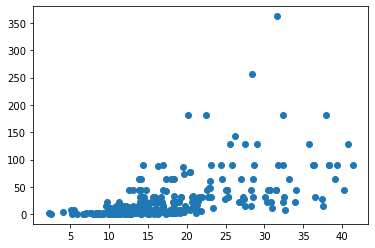

In [23]:
plt.scatter(predicted_score,experiment_score)

<AxesSubplot:xlabel='group', ylabel='value'>

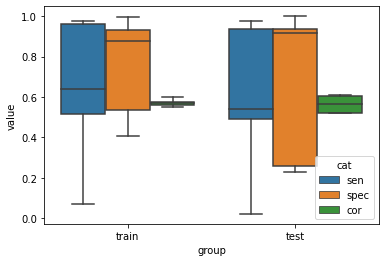

In [24]:
dd = pd.concat(perf)
sns.boxplot(data=dd, x="group", y="value", hue="cat")

In [2279]:
#6. interpretability

In [2280]:
regr.fit(X_train_array, Y_train_array)

/opt/anaconda3/lib/python3.9/site-packages/sklearn/svm/_base.py:1206: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


LinearSVR()

In [2121]:
prediction, bias, contributions = ti.predict(regr, np.array([X_train_array[0]]))

<AxesSubplot:xlabel='variable', ylabel='value'>

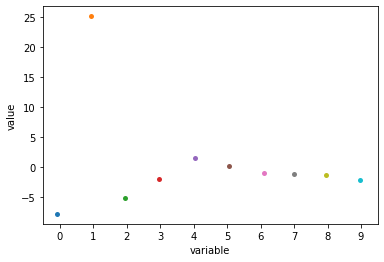

In [2122]:
pt = pd.DataFrame(contributions).melt()
sns.stripplot(data=pt , x="variable", y="value")

In [2123]:
#7. check the protein structure|

In [2124]:
ALL = []
for cnt,u in enumerate(["H1N1","H3N2","H5N1","H9N2"]):
    
    dat = pd.read_csv("HI_assay/curate_02/"+u+"_antigenicData", header=None,sep="\t")
    seq_ =  SeqIO.to_dict(SeqIO.parse("HI_assay/curate_02/"+u+"_AA.fa", "fasta"))
    struct_pos = pd.read_csv("HI_assay/curate_02/band/epitopeByDist2top_"+u[:2], header=None)
    #dat.shape[0]
    for i in range(dat.shape[0]):

        s1 = dat.iloc[i,0]
        s2 = dat.iloc[i,1]
        score_train = dat.iloc[i,2]

        s1_seq = str(seq_[s1].seq)
        s2_seq = str(seq_[s2].seq)

        #get score
        score_ = []
        for j in range(len(s1_seq)):

            pos_1 = s1_seq[j]
            pos_2 = s2_seq[j]
            
            if pos_1 == '-' or pos_2 == '-':
                score_.append(2)
            else:

                if pos_1 == pos_2:
                    score_.append(0)
                else:
                    score_.append(1)
        dict_df = []
        for k in range(10):
            ban=struct_pos.iloc[k,:]
            index_ = ban.tolist()[0].split('\t')[1:]
            QC_index = [int(z)-1 for z in index_]
    
            act = []
            for ss in QC_index:
                try:
                    act.append(score_[ss])
                except:
                    pass

                
            df_mut = pd.DataFrame(act,columns=["mutation"])
            df_mut["band"] = k
            dict_df.append(df_mut)
            
        df_cnt = pd.concat(dict_df).query("mutation != 2").groupby("band").sum().reset_index()
        df_cnt.columns = ["band","mut"]
        
        df_cnt["sample_"] = i
        df_cnt["subtype"] = u
        
        ALL.append(df_cnt)

            

In [2125]:
df_plot = pd.concat(ALL)

<AxesSubplot:xlabel='band', ylabel='mut'>

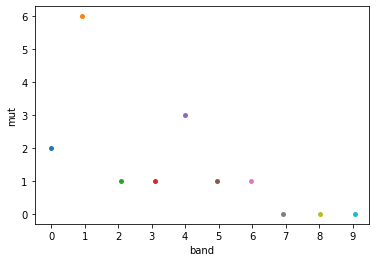

In [2126]:
sns.stripplot(data=df_plot.query("sample_ == 0").query("subtype == 'H1N1'"), x="band", y="mut")